In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_object_dtype
from scipy.stats import gaussian_kde

def plot_dataframe_distributions(df, max_cols=3, figsize_per_plot=(5, 4), save_path=None):
    """
    自動繪製 DataFrame 中每個欄位的分布圖，數值欄位用 KDE，字串欄位用長條圖。
    色彩設計：淺藍色填色，深灰色邊框。

    Parameters:
        df : pandas.DataFrame
        max_cols : 每列最多圖表數
        figsize_per_plot : 每個 subplot 的大小 (寬, 高)
        save_path : 若指定檔案路徑，則將整張圖另存為檔案
    """
    n_vars = df.shape[1]
    cols = min(n_vars, max_cols)
    rows = math.ceil(n_vars / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per_plot[0]*cols, figsize_per_plot[1]*rows))
    axes = np.array(axes).reshape(rows, cols)

    for idx, column in enumerate(df.columns):
        r, c = divmod(idx, cols)
        ax = axes[r][c]
        series = df[column].dropna()

        # value_counts = series.astype(str).value_counts().sort_index()
        # ax.bar(value_counts.index, value_counts.values, color="#ADD8E6", edgecolor="#444444", linewidth=1.2)

        # ax.set_xlabel(column)
        # ax.set_ylabel("Count")
        # ax.set_xticks(range(len(value_counts)))
        # ax.set_xticklabels(value_counts.index, rotation=45, ha='right')

        if is_numeric_dtype(series):
            # 數值欄位：使用 KDE
            x_vals = np.linspace(series.min(), series.max(), 200)
            kde = gaussian_kde(series)
            y_vals = kde(x_vals)

            ax.fill_between(x_vals, y_vals, color="#ADD8E6", edgecolor="#444444", linewidth=1.5)

            # 合理化 x 軸刻度
            xmin = math.floor(series.min())
            xmax = math.ceil(series.max())
            xticks = list(range(xmin, xmax + 1)) if xmax - xmin <= 10 else np.linspace(xmin, xmax, 6)
            # ax.set_xticks(xticks)

            ax.set_xlabel(column)
            ax.set_ylabel("Density")

        elif is_string_dtype(series) or is_object_dtype(series):
            # 類別欄位：使用長條圖
            value_counts = series.astype(str).value_counts().sort_index()
            ax.bar(value_counts.index, value_counts.values, color="#ADD8E6", edgecolor="#444444", linewidth=1.2)

            ax.set_xlabel(column)
            ax.set_ylabel("Count")
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=45, ha='right')

        else:
            # 不支援的資料型別
            ax.text(0.5, 0.5, f'Unsupported\ndtype: {series.dtype}', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])

        # ax.set_title(column)

    # 移除多餘的空 subplot（如果欄位數不足）
    for idx in range(n_vars, rows * cols):
        r, c = divmod(idx, cols)
        fig.delaxes(axes[r][c])

    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [19]:
df = pd.read_csv("data_0611_4.csv")  # 或任意 DataFrame
df.drop(columns=['score','navigation_std_click_interval', 'output_std_click_interval', 'input_std_click_interval'], inplace=True) #'homepage_std_click_interval', 

df.columns

Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
       'studied_credits', 'date_registration', 'late_ratio',
       'completion_ratio', 'navigation_mean_click_interval',
       'navigation_mean_clicks', 'navigation_click_variance',
       'input_mean_click_interval', 'input_mean_clicks',
       'input_click_variance', 'output_mean_click_interval',
       'output_mean_clicks', 'output_click_variance', 'early_score',
       'late_score', 'mid_score', 'module_presentation'],
      dtype='object')

In [24]:
df1 = df[['module_presentation', 'region', 'highest_education', 'imd_band', 'gender', 'age_band',
       'studied_credits', 'date_registration', ]]
df2 = df[['late_ratio', 'completion_ratio']]
df3 = df[['early_score', 'late_score', 'mid_score']]
df4 = df[['navigation_mean_click_interval',
       'navigation_mean_clicks', 'navigation_click_variance',
       'input_mean_click_interval', 'input_mean_clicks',
       'input_click_variance', 'output_mean_click_interval',
       'output_mean_clicks', 'output_click_variance']]

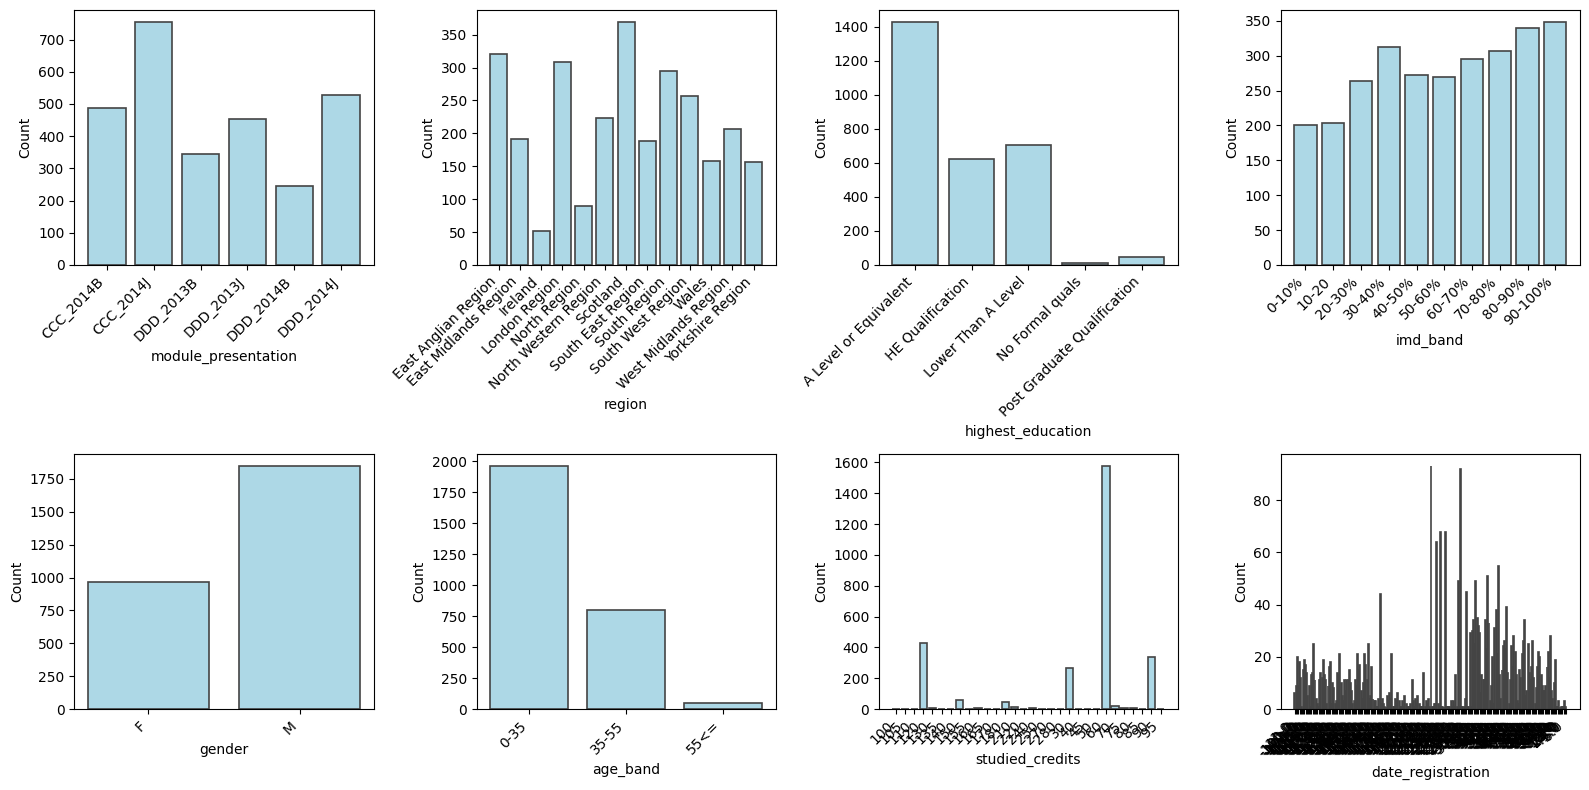

In [33]:
plot_dataframe_distributions(df1, max_cols=4, figsize_per_plot=(4, 4))

,studied_credits,date_registration
count,2811.000000,2811.000000
mean,76.049449,-72.353967
std,34.749250,51.100727
min,30.000000,-310.000000
25%,60.000000,-103.000000
50%,60.000000,-58.000000
75%,90.000000,-30.000000
max,280.000000,49.000000


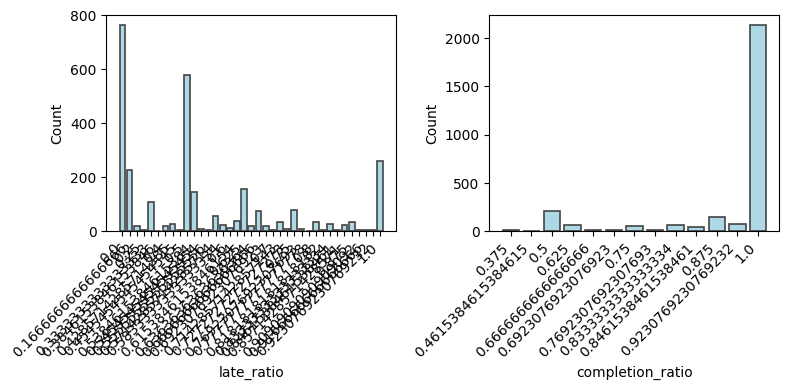

In [34]:
plot_dataframe_distributions(df2, max_cols=4, figsize_per_plot=(4, 4))

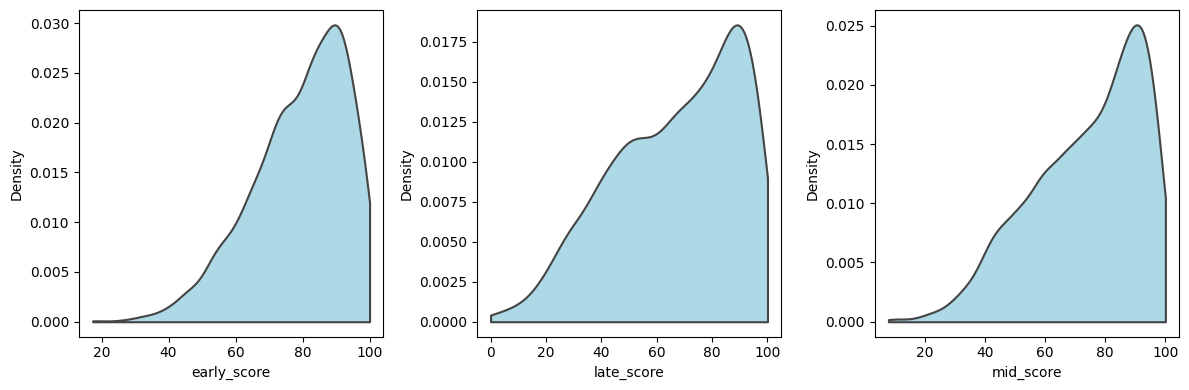

In [29]:
plot_dataframe_distributions(df3, max_cols=3, figsize_per_plot=(4, 4))

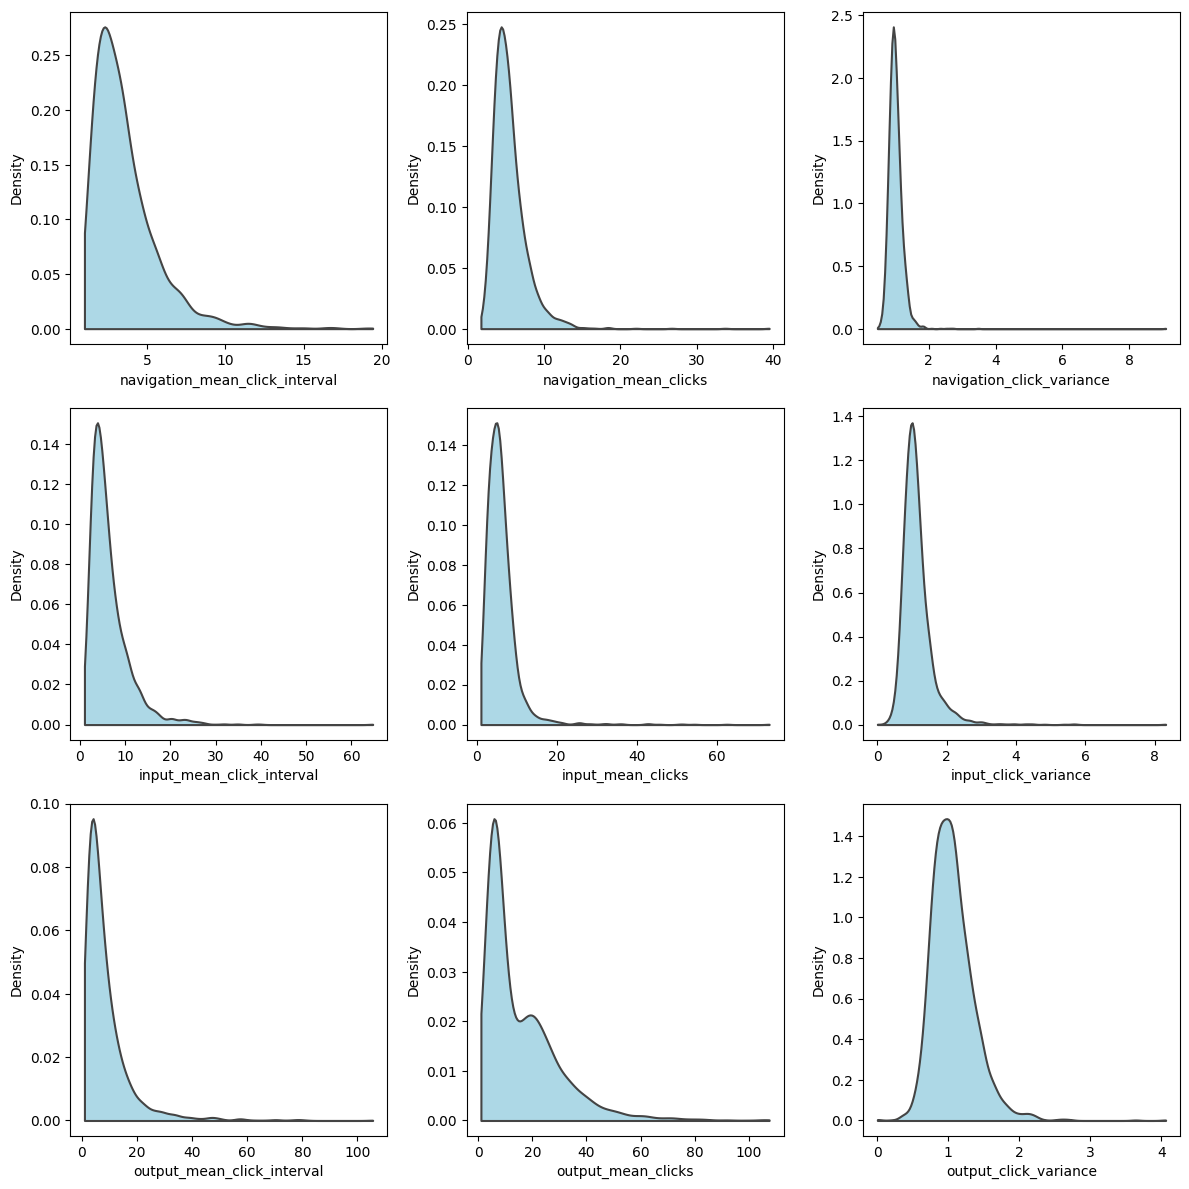

In [30]:
plot_dataframe_distributions(df4, max_cols=3, figsize_per_plot=(4, 4))

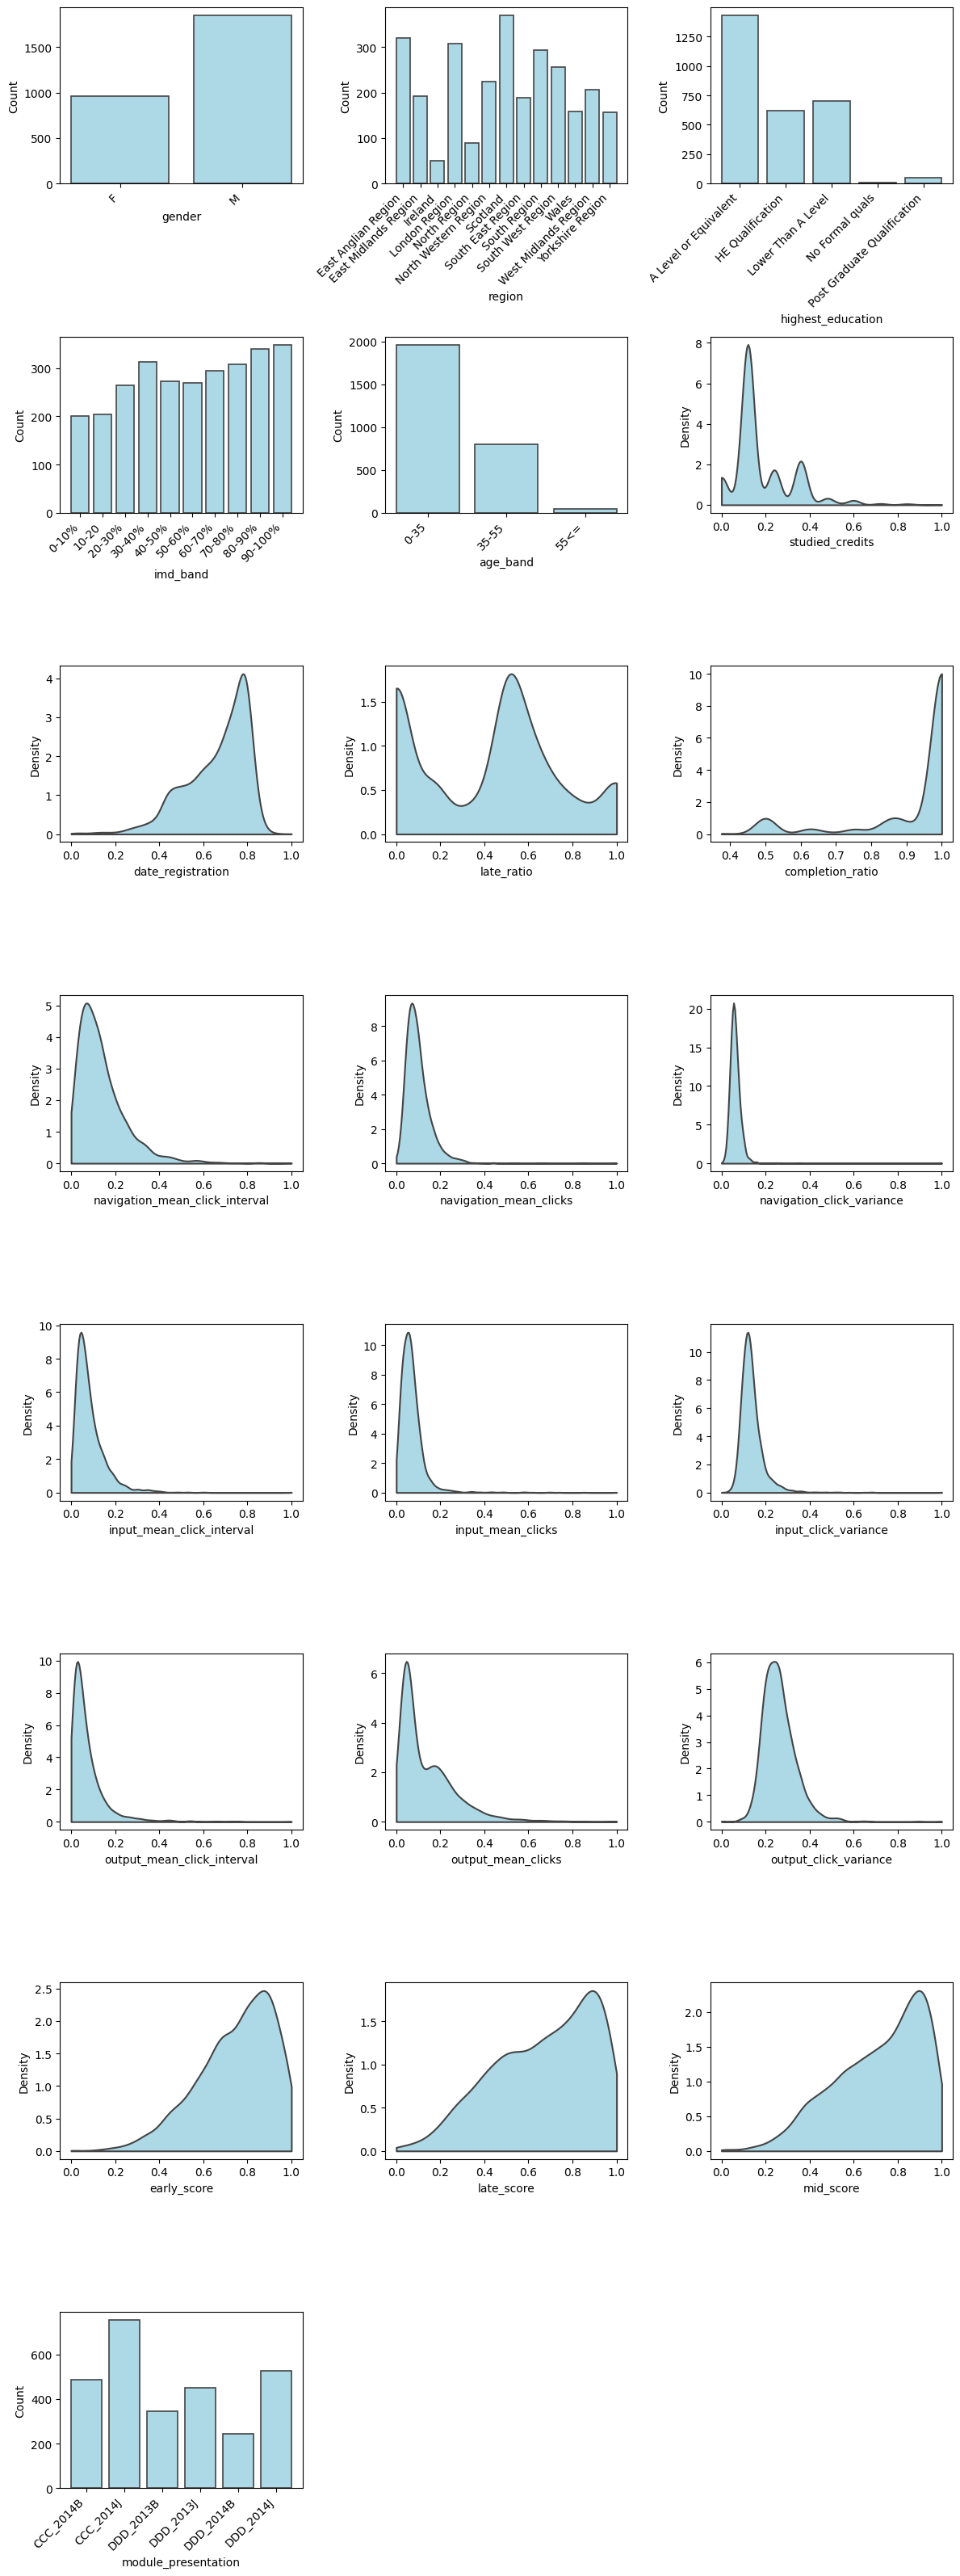

In [3]:
data = pd.read_csv("data_0611_4_normalized.csv")  # 或任意 DataFrame
data.drop(columns=['score','navigation_std_click_interval', 'output_std_click_interval', 'input_std_click_interval'], inplace=True) #'homepage_std_click_interval',
plot_dataframe_distributions(data, max_cols=3, figsize_per_plot=(4, 4))